# **Model with Food Price Features**

This notebook tests whether adding food price features improves the drought and food security early-warning model.

The previous modeling dataset used:

- IPC outcome variables
- Rainfall features
- NDVI vegetation features

The new dataset adds:

- County-level food price features where available
- National food price proxy features
- Final hybrid staple food price features

The goal is to compare model performance before and after adding food price features.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Project paths
PROCESSED_DIR = Path("../02_data/processed")

# Input file
FOOD_PRICE_MASTER_FILE = PROCESSED_DIR / "ipc_rainfall_ndvi_food_price_master_dataset.csv"

In [2]:
# Load final master dataset with food price features

df = pd.read_csv(FOOD_PRICE_MASTER_FILE)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (322, 51)


,ipc_date,analysis_period,county,max_ipc_phase,phase_3_plus_population,total_population,phase_3_plus_percentage,rainfall_date,mean_rainfall_mm,rainfall_3_month_total,...,national_beans_price_per_kg_6_month_avg,national_rice_price_per_kg_3_month_avg,national_rice_price_per_kg_6_month_avg,national_staple_price_per_kg_3_month_avg,national_staple_price_per_kg_6_month_avg,final_staple_price_per_kg,final_staple_price_per_kg_3_month_avg,final_staple_price_per_kg_6_month_avg,food_price_source,county_food_price_matched
0,2019-07-01,Jul 2019,Baringo,4,105555,703697,0.15,2019-06-01,72.692665,143.441454,...,82.49896,NaN,NaN,68.793937,62.643993,97.450000,87.316667,94.075000,county,1
1,2019-07-01,Jul 2019,Embu,3,32883,219220,0.15,2019-06-01,8.068131,123.946965,...,82.49896,NaN,NaN,68.793937,62.643993,71.969014,68.793937,62.643993,national_proxy,0
2,2019-07-01,Jul 2019,Garissa,4,151183,431950,0.35,2019-06-01,5.417682,55.185197,...,82.49896,NaN,NaN,68.793937,62.643993,68.000000,66.666667,65.833333,county,1
3,2019-07-01,Jul 2019,Isiolo,4,54413,155465,0.35,2019-06-01,0.936229,26.591658,...,82.49896,NaN,NaN,68.793937,62.643993,71.969014,68.793937,62.643993,national_proxy,0
4,2019-07-01,Jul 2019,Kajiado,3,43536,870721,0.05,2019-06-01,6.391582,62.716861,...,82.49896,NaN,NaN,68.793937,62.643993,76.700000,76.066667,74.033333,county,1


## **Dataset Overview**

The dataset loaded in this notebook is the final master dataset created in Notebook 13.

It includes IPC, rainfall, NDVI, and food price features.

The target variable will remain the same as in the previous modeling notebooks so that model performance can be compared fairly.

In [3]:
# Inspect available columns

print("Columns:")
print(df.columns.tolist())

Columns:
['ipc_date', 'analysis_period', 'county', 'max_ipc_phase', 'phase_3_plus_population', 'total_population', 'phase_3_plus_percentage', 'rainfall_date', 'mean_rainfall_mm', 'rainfall_3_month_total', 'rainfall_6_month_total', 'rainfall_3_month_avg', 'rainfall_6_month_avg', 'date', 'mean_ndvi', 'ndvi_1_month_mean', 'ndvi_3_month_mean', 'ndvi_6_month_mean', 'ndvi_anomaly', 'month', 'county_beans_price_per_kg', 'county_maize_price_per_kg', 'county_rice_price_per_kg', 'county_staple_price_per_kg', 'county_price_available', 'county_staple_items_available', 'county_maize_price_per_kg_3_month_avg', 'county_maize_price_per_kg_6_month_avg', 'county_beans_price_per_kg_3_month_avg', 'county_beans_price_per_kg_6_month_avg', 'county_rice_price_per_kg_3_month_avg', 'county_rice_price_per_kg_6_month_avg', 'county_staple_price_per_kg_3_month_avg', 'county_staple_price_per_kg_6_month_avg', 'national_beans_price_per_kg', 'national_maize_price_per_kg', 'national_rice_price_per_kg', 'national_staple_

In [4]:
# Create binary target variable
# High risk = IPC Phase 3+ population percentage >= 20%

df["high_food_insecurity_risk"] = np.where(
    df["phase_3_plus_percentage"] >= 0.20,
    1,
    0
)

print(df["high_food_insecurity_risk"].value_counts())
print(df["high_food_insecurity_risk"].value_counts(normalize=True).round(3))

high_food_insecurity_risk
0    230
1     92
Name: count, dtype: int64
high_food_insecurity_risk
0    0.714
1    0.286
Name: proportion, dtype: float64


## **Target Variable Distribution**

The binary target variable `high_food_insecurity_risk` was created using the IPC Phase 3+ population percentage.

A record is labelled as high risk if `phase_3_plus_percentage` is greater than or equal to 20%.

The target distribution shows that most records are lower risk, while a smaller share are high risk.

This means the dataset is moderately imbalanced. To handle this, the models will use balanced class weights where possible.

In [5]:
# Select baseline environmental features

baseline_features = [
    "mean_rainfall_mm",
    "rainfall_3_month_total",
    "rainfall_6_month_total",
    "rainfall_3_month_avg",
    "rainfall_6_month_avg",
    "mean_ndvi",
    "ndvi_1_month_mean",
    "ndvi_3_month_mean",
    "ndvi_6_month_mean",
    "ndvi_anomaly"
]

# Select food price features

food_price_features = [
    "final_staple_price_per_kg",
    "final_staple_price_per_kg_3_month_avg",
    "final_staple_price_per_kg_6_month_avg",
    "county_food_price_matched"
]

# Combined feature set

model_features = baseline_features + food_price_features

target_col = "high_food_insecurity_risk"

print("Number of model features:", len(model_features))
print(model_features)

Number of model features: 14
['mean_rainfall_mm', 'rainfall_3_month_total', 'rainfall_6_month_total', 'rainfall_3_month_avg', 'rainfall_6_month_avg', 'mean_ndvi', 'ndvi_1_month_mean', 'ndvi_3_month_mean', 'ndvi_6_month_mean', 'ndvi_anomaly', 'final_staple_price_per_kg', 'final_staple_price_per_kg_3_month_avg', 'final_staple_price_per_kg_6_month_avg', 'county_food_price_matched']


In [6]:
# Prepare X and y

model_df = df.dropna(subset=[target_col]).copy()

X = model_df[model_features]
y = model_df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (322, 14)
y shape: (322,)

Target distribution:
high_food_insecurity_risk
0    230
1     92
Name: count, dtype: int64


In [7]:
# Convert date and sort by time

model_df["ipc_date"] = pd.to_datetime(model_df["ipc_date"], errors="coerce")
model_df = model_df.sort_values("ipc_date").copy()

X = model_df[model_features]
y = model_df[target_col]

# Time-aware split: first 80% train, last 20% test

split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

Train shape: (257, 14)
Test shape: (65, 14)

Train target distribution:
high_food_insecurity_risk
0    181
1     76
Name: count, dtype: int64

Test target distribution:
high_food_insecurity_risk
0    49
1    16
Name: count, dtype: int64


## **Logistic Regression Model with Food Price Features**

This section trains a Logistic Regression model using rainfall, NDVI, and food price features.

Logistic Regression is used as an interpretable baseline model. It helps us understand whether adding food price indicators improves the model’s ability to classify high food insecurity risk.

Because the target classes are not perfectly balanced, the model uses balanced class weights.

In [8]:
# Logistic Regression model with scaling and missing value handling

logreg_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

logreg_model.fit(X_train, y_train)

logreg_preds = logreg_model.predict(X_test)

print("Logistic Regression with food price features")
print("Accuracy:", accuracy_score(y_test, logreg_preds))
print("F1 Score:", f1_score(y_test, logreg_preds))

print("\nClassification Report:")
print(classification_report(y_test, logreg_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logreg_preds))

Logistic Regression with food price features
Accuracy: 0.7846153846153846
F1 Score: 0.6818181818181818

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.73      0.84        49
           1       0.54      0.94      0.68        16

    accuracy                           0.78        65
   macro avg       0.75      0.84      0.76        65
weighted avg       0.87      0.78      0.80        65


Confusion Matrix:
[[36 13]
 [ 1 15]]


## **Logistic Regression Result Interpretation**

The Logistic Regression model with food price features achieved an accuracy of about 78.5% and an F1 score of about 68.2%.

The model performed especially well at detecting high food insecurity risk cases. It correctly identified 15 out of 16 high-risk records in the test set, missing only 1 high-risk case.

This gives the model a high recall for the high-risk class. High recall is useful for an early-warning system because missing a serious food insecurity case can be costly.

However, the model also produced some false alarms. It predicted 13 lower-risk records as high risk. This means the model is cautious: it catches most danger cases, but sometimes raises warnings where the actual risk is lower.

Overall, the result is promising for an early-warning use case because the model prioritizes detecting high-risk counties.

## **Random Forest Model with Food Price Features**

This section trains a Random Forest model using rainfall, NDVI, and food price features.

Random Forest is a tree-based model that can capture non-linear relationships between climate, vegetation, market prices, and food insecurity risk.

The model uses balanced class weights because the dataset has fewer high-risk records than lower-risk records.

In [9]:
# Random Forest model with missing value handling

rf_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest with food price features")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("F1 Score:", f1_score(y_test, rf_preds))

print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_preds))

Random Forest with food price features
Accuracy: 0.8461538461538461
F1 Score: 0.7222222222222222

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.86      0.89        49
           1       0.65      0.81      0.72        16

    accuracy                           0.85        65
   macro avg       0.79      0.83      0.81        65
weighted avg       0.86      0.85      0.85        65


Confusion Matrix:
[[42  7]
 [ 3 13]]


## **Random Forest Result Interpretation**

The Random Forest model with food price features achieved an accuracy of about 84.6% and an F1 score of about 72.2%.

This is a strong result for the food price feature experiment.

The model correctly identified 13 out of 16 high-risk records in the test set. It missed 3 high-risk records and produced 7 false alarms.

Compared with Logistic Regression, Random Forest achieved better overall accuracy and a better F1 score. It also reduced false alarms, but it missed slightly more high-risk cases.

This suggests that Random Forest may be better at balancing precision and recall, while Logistic Regression is more aggressive at detecting high-risk cases.

For an early-warning system, the best model choice depends on the project goal:

- If the priority is to catch almost every high-risk case, Logistic Regression may be useful because it had higher recall.
- If the priority is better overall balance and fewer false alarms, Random Forest is stronger.

## **XGBoost Model with Food Price Features**

This section trains an XGBoost model using rainfall, NDVI, and food price features.

XGBoost is a powerful tree-based boosting model. It can capture non-linear patterns and interactions between climate, vegetation, and food price indicators.

The model is tested to see whether it performs better than Logistic Regression and Random Forest after food price features are added.

In [10]:
# XGBoost model with food price features

try:
    from xgboost import XGBClassifier
    
    xgb_model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        ))
    ])
    
    xgb_model.fit(X_train, y_train)
    
    xgb_preds = xgb_model.predict(X_test)
    
    print("XGBoost with food price features")
    print("Accuracy:", accuracy_score(y_test, xgb_preds))
    print("F1 Score:", f1_score(y_test, xgb_preds))
    
    print("\nClassification Report:")
    print(classification_report(y_test, xgb_preds))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, xgb_preds))

except ImportError:
    print("XGBoost is not installed in this environment.")
    print("Install it with: pip install xgboost")

XGBoost with food price features
Accuracy: 0.8923076923076924
F1 Score: 0.7878787878787878

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93        49
           1       0.76      0.81      0.79        16

    accuracy                           0.89        65
   macro avg       0.85      0.87      0.86        65
weighted avg       0.89      0.89      0.89        65


Confusion Matrix:
[[45  4]
 [ 3 13]]


## **XGBoost Result Interpretation**

The XGBoost model with food price features achieved the strongest performance so far.

It reached an accuracy of about 89.2% and an F1 score of about 0.79.

The model correctly identified 13 out of 16 high-risk records in the test set. It missed 3 high-risk records and produced 4 false alarms.

Compared with Logistic Regression and Random Forest, XGBoost achieved the best overall balance between detecting high-risk food insecurity cases and avoiding false alarms.

This suggests that the combination of rainfall, NDVI, and food price features provides useful predictive signal, especially when used with a boosted tree-based model.

## **Model Comparison**

This section compares the models trained with food price features.

The comparison focuses on:

- Accuracy
- F1 score
- Precision for high-risk cases
- Recall for high-risk cases

For this project, recall for the high-risk class is especially important because an early-warning model should avoid missing serious food insecurity risk cases.

In [11]:
from sklearn.metrics import precision_score, recall_score

# Create comparison table for models with food price features

model_results = pd.DataFrame([
    {
        "model": "Logistic Regression + Food Prices",
        "accuracy": accuracy_score(y_test, logreg_preds),
        "f1_score": f1_score(y_test, logreg_preds),
        "precision_high_risk": precision_score(y_test, logreg_preds),
        "recall_high_risk": recall_score(y_test, logreg_preds)
    },
    {
        "model": "Random Forest + Food Prices",
        "accuracy": accuracy_score(y_test, rf_preds),
        "f1_score": f1_score(y_test, rf_preds),
        "precision_high_risk": precision_score(y_test, rf_preds),
        "recall_high_risk": recall_score(y_test, rf_preds)
    },
    { 
        "model": "XGBoost + Food Prices",
        "accuracy": accuracy_score(y_test, xgb_preds),
        "f1_score": f1_score(y_test, xgb_preds),
        "precision_high_risk": precision_score(y_test, xgb_preds),
        "recall_high_risk": recall_score(y_test, xgb_preds)
    }
])

model_results

,model,accuracy,f1_score,precision_high_risk,recall_high_risk
0,Logistic Regression + Food Prices,0.784615,0.681818,0.535714,0.9375
1,Random Forest + Food Prices,0.846154,0.722222,0.650000,0.8125
2,XGBoost + Food Prices,0.892308,0.787879,0.764706,0.8125


## **Model Results with Food Price Features**

The updated model results table now includes all three models trained with food price features:

- Logistic Regression
- Random Forest
- XGBoost

XGBoost achieved the strongest overall performance, with the highest accuracy and highest F1 score.

From the results:

- Logistic Regression achieved an accuracy of about 78.5% and an F1 score of about 0.68.
- Random Forest achieved an accuracy of about 84.6% and an F1 score of about 0.72.
- XGBoost achieved an accuracy of about 89.2% and an F1 score of about 0.79.

XGBoost also had the strongest high-risk precision, meaning it produced fewer false alarms compared with the other models.

Logistic Regression had the highest high-risk recall, meaning it detected the largest share of actual high-risk cases.

Overall, XGBoost is the best balanced model after adding food price features, while Logistic Regression remains useful when the main priority is catching nearly all high-risk cases.

## **Baseline vs Food Price Model Comparison**

This section compares model performance before and after adding food price features.

The baseline results come from Notebook 09, where the models used rainfall and NDVI features only.

The new results come from this notebook, where the models use rainfall, NDVI, and food price features.

This comparison helps answer the main question:

Did food price indicators improve the early-warning model?

In [12]:
from sklearn.metrics import precision_score, recall_score

# Baseline results from Notebook 09: rainfall + NDVI only
baseline_results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "feature_set": "Rainfall + NDVI",
        "accuracy": 0.7692,
        "precision_high_risk": 0.5172,
        "recall_high_risk": 0.9375,
        "f1_score": 0.6667,
        "roc_auc": 0.9171
    },
    {
        "model": "Standardized Logistic Regression",
        "feature_set": "Rainfall + NDVI",
        "accuracy": 0.7692,
        "precision_high_risk": 0.5172,
        "recall_high_risk": 0.9375,
        "f1_score": 0.6667,
        "roc_auc": 0.9298
    },
    {
        "model": "Random Forest",
        "feature_set": "Rainfall + NDVI",
        "accuracy": 0.8769,
        "precision_high_risk": 0.7222,
        "recall_high_risk": 0.8125,
        "f1_score": 0.7647,
        "roc_auc": 0.9286
    },
    {
        "model": "XGBoost",
        "feature_set": "Rainfall + NDVI",
        "accuracy": 0.8769,
        "precision_high_risk": 0.7000,
        "recall_high_risk": 0.8750,
        "f1_score": 0.7778,
        "roc_auc": 0.9362
    }
])

# Current results from Notebook 14: rainfall + NDVI + food prices
food_price_results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "feature_set": "Rainfall + NDVI + Food Prices",
        "accuracy": accuracy_score(y_test, logreg_preds),
        "precision_high_risk": precision_score(y_test, logreg_preds),
        "recall_high_risk": recall_score(y_test, logreg_preds),
        "f1_score": f1_score(y_test, logreg_preds),
        "roc_auc": np.nan
    },
    {
        "model": "Random Forest",
        "feature_set": "Rainfall + NDVI + Food Prices",
        "accuracy": accuracy_score(y_test, rf_preds),
        "precision_high_risk": precision_score(y_test, rf_preds),
        "recall_high_risk": recall_score(y_test, rf_preds),
        "f1_score": f1_score(y_test, rf_preds),
        "roc_auc": np.nan
    },
    {
        "model": "XGBoost",
        "feature_set": "Rainfall + NDVI + Food Prices",
        "accuracy": accuracy_score(y_test, xgb_preds),
        "precision_high_risk": precision_score(y_test, xgb_preds),
        "recall_high_risk": recall_score(y_test, xgb_preds),
        "f1_score": f1_score(y_test, xgb_preds),
        "roc_auc": np.nan
    }
])

comparison_results = pd.concat(
    [baseline_results, food_price_results],
    ignore_index=True
)

comparison_results.sort_values(["model", "feature_set"])

,model,feature_set,accuracy,precision_high_risk,recall_high_risk,f1_score,roc_auc
0,Logistic Regression,Rainfall + NDVI,0.769200,0.517200,0.9375,0.666700,0.9171
4,Logistic Regression,Rainfall + NDVI + Food Prices,0.784615,0.535714,0.9375,0.681818,NaN
2,Random Forest,Rainfall + NDVI,0.876900,0.722200,0.8125,0.764700,0.9286
5,Random Forest,Rainfall + NDVI + Food Prices,0.846154,0.650000,0.8125,0.722222,NaN
1,Standardized Logistic Regression,Rainfall + NDVI,0.769200,0.517200,0.9375,0.666700,0.9298
3,XGBoost,Rainfall + NDVI,0.876900,0.700000,0.8750,0.777800,0.9362
6,XGBoost,Rainfall + NDVI + Food Prices,0.892308,0.764706,0.8125,0.787879,NaN


In [13]:
# Compare before vs after food prices for matching model types

before_after_comparison = comparison_results.pivot_table(
    index="model",
    columns="feature_set",
    values=["accuracy", "precision_high_risk", "recall_high_risk", "f1_score"],
    aggfunc="first"
)

before_after_comparison

accuracy  \
feature_set                      Rainfall + NDVI   
model                                              
Logistic Regression                       0.7692   
Random Forest                             0.8769   
Standardized Logistic Regression          0.7692   
XGBoost                                   0.8769   

                                                                \
feature_set                      Rainfall + NDVI + Food Prices   
model                                                            
Logistic Regression                                   0.784615   
Random Forest                                         0.846154   
Standardized Logistic Regression                           NaN   
XGBoost                                               0.892308   

                                        f1_score  \
feature_set                      Rainfall + NDVI   
model                                              
Logistic Regression                       0.6667   
Random Forest                             0.7647   
Standardized Logistic Regression          0.6667   
XGBoost                                   0.7778   

                                                                \
feature_set                      Rainfall + NDVI + Food Prices   
model                                                            
Logistic Regression                                   0.681818   
Random Forest                                         0.722222   
Standardized Logistic Regression                           NaN   
XGBoost                                               0.787879   

                                 precision_high_risk  \
feature_set                          Rainfall + NDVI   
model                                                  
Logistic Regression                           0.5172   
Random Forest                                 0.7222   
Standardized Logistic Regression              0.5172   
XGBoost                                       0.7000   

                                                                \
feature_set                      Rainfall + NDVI + Food Prices   
model                                                            
Logistic Regression                                   0.535714   
Random Forest                                         0.650000   
Standardized Logistic Regression                           NaN   
XGBoost                                               0.764706   

                                 recall_high_risk  \
feature_set                       Rainfall + NDVI   
model                                               
Logistic Regression                        0.9375   
Random Forest                              0.8125   
Standardized Logistic Regression           0.9375   
XGBoost                                    0.8750   

                                                                
feature_set                      Rainfall + NDVI + Food Prices  
model                                                           
Logistic Regression                                     0.9375  
Random Forest                                           0.8125  
Standardized Logistic Regression                           NaN  
XGBoost                                                 0.8125

## **Baseline vs Food Price Model Comparison Results**

The comparison shows that adding food price features affected each model differently.

Logistic Regression improved slightly after food price features were added. Its accuracy, precision, and F1 score increased, while high-risk recall stayed the same.

Random Forest performed slightly worse after adding food price features. Its accuracy, precision, and F1 score decreased, while recall stayed the same.

XGBoost achieved the strongest overall result after adding food price features. It had the highest accuracy and highest F1 score among the tested models. Its precision improved, meaning it produced fewer false alarms, but its recall decreased slightly compared with the baseline XGBoost model.

Overall, the food price features appear most useful for XGBoost and slightly useful for Logistic Regression. They did not improve Random Forest in this experiment.

For the first food price modeling version, XGBoost with rainfall, NDVI, and food price features is the strongest overall model. However, Logistic Regression remains useful as a high-recall early-warning baseline because it detects the largest share of high-risk cases.

In [14]:
# Calculate improvement after adding food price features

baseline_simple = baseline_results[
    baseline_results["model"].isin(["Logistic Regression", "Random Forest", "XGBoost"])
].copy()

food_price_simple = food_price_results.copy()

improvement_comparison = baseline_simple.merge(
    food_price_simple,
    on="model",
    suffixes=("_before_food_prices", "_after_food_prices")
)

improvement_comparison["accuracy_change"] = (
    improvement_comparison["accuracy_after_food_prices"] -
    improvement_comparison["accuracy_before_food_prices"]
)

improvement_comparison["f1_score_change"] = (
    improvement_comparison["f1_score_after_food_prices"] -
    improvement_comparison["f1_score_before_food_prices"]
)

improvement_comparison["precision_change"] = (
    improvement_comparison["precision_high_risk_after_food_prices"] -
    improvement_comparison["precision_high_risk_before_food_prices"]
)

improvement_comparison["recall_change"] = (
    improvement_comparison["recall_high_risk_after_food_prices"] -
    improvement_comparison["recall_high_risk_before_food_prices"]
)

improvement_table = improvement_comparison[
    [
        "model",
        "accuracy_before_food_prices",
        "accuracy_after_food_prices",
        "accuracy_change",
        "f1_score_before_food_prices",
        "f1_score_after_food_prices",
        "f1_score_change",
        "precision_high_risk_before_food_prices",
        "precision_high_risk_after_food_prices",
        "precision_change",
        "recall_high_risk_before_food_prices",
        "recall_high_risk_after_food_prices",
        "recall_change"
    ]
].sort_values("f1_score_after_food_prices", ascending=False)

improvement_table

,model,accuracy_before_food_prices,accuracy_after_food_prices,accuracy_change,f1_score_before_food_prices,f1_score_after_food_prices,f1_score_change,precision_high_risk_before_food_prices,precision_high_risk_after_food_prices,precision_change,recall_high_risk_before_food_prices,recall_high_risk_after_food_prices,recall_change
2,XGBoost,0.8769,0.892308,0.015408,0.7778,0.787879,0.010079,0.7000,0.764706,0.064706,0.8750,0.8125,-0.0625
1,Random Forest,0.8769,0.846154,-0.030746,0.7647,0.722222,-0.042478,0.7222,0.650000,-0.072200,0.8125,0.8125,0.0000
0,Logistic Regression,0.7692,0.784615,0.015415,0.6667,0.681818,0.015118,0.5172,0.535714,0.018514,0.9375,0.9375,0.0000


## **Food Price Feature Improvement Results**

The improvement table shows that adding food price features affected the models differently.

XGBoost improved after adding food prices. It achieved higher accuracy, higher F1 score, and higher precision for high-risk cases. This means the model became better at making correct high-risk predictions and reducing false alarms. However, its high-risk recall decreased slightly, meaning it missed a few more high-risk cases than before.

Logistic Regression also improved slightly after adding food prices. Its accuracy, precision, and F1 score increased, while high-risk recall stayed the same. This makes it useful as a high-recall early-warning baseline.

Random Forest did not improve after adding food prices. Its accuracy, precision, and F1 score decreased, while recall stayed the same.

Overall, the food price features were most useful for XGBoost. The best overall model is XGBoost with rainfall, NDVI, and food price features. However, Logistic Regression remains useful when the main priority is detecting as many high-risk cases as possible.

## **Visual Comparison of Model Performance**

This section visualizes how model performance changed after adding food price features.

The chart compares F1 scores before and after food price features for each model.

F1 score is useful because it balances precision and recall for the high-risk class.

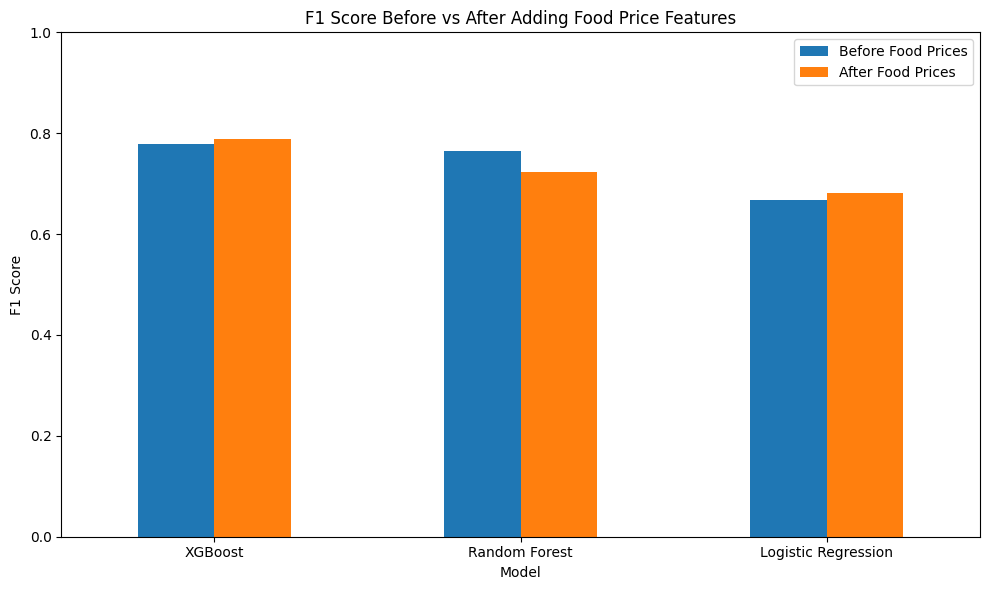

In [15]:
import matplotlib.pyplot as plt

# Prepare data for F1 score comparison chart

f1_chart_data = improvement_table[
    [
        "model",
        "f1_score_before_food_prices",
        "f1_score_after_food_prices"
    ]
].copy()

f1_chart_data = f1_chart_data.set_index("model")

# Plot F1 score comparison

ax = f1_chart_data.plot(kind="bar", figsize=(10, 6))

plt.title("F1 Score Before vs After Adding Food Price Features")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(["Before Food Prices", "After Food Prices"])
plt.tight_layout()
plt.show()

## **F1 Score Chart Interpretation**

The F1 score chart shows that adding food price features had different effects across the models.

XGBoost had the strongest F1 score after food price features were added. Logistic Regression improved slightly, while Random Forest decreased.

This supports the earlier table result: food price features were most useful for XGBoost and slightly useful for Logistic Regression, but they did not improve Random Forest in this experiment.

## **High-Risk Precision and Recall Comparison**

This section compares precision and recall for the high-risk class after adding food price features.

Precision shows how many predicted high-risk cases were truly high risk.

Recall shows how many actual high-risk cases the model successfully detected.

For an early-warning system, recall is especially important because missing a high-risk case can be costly.

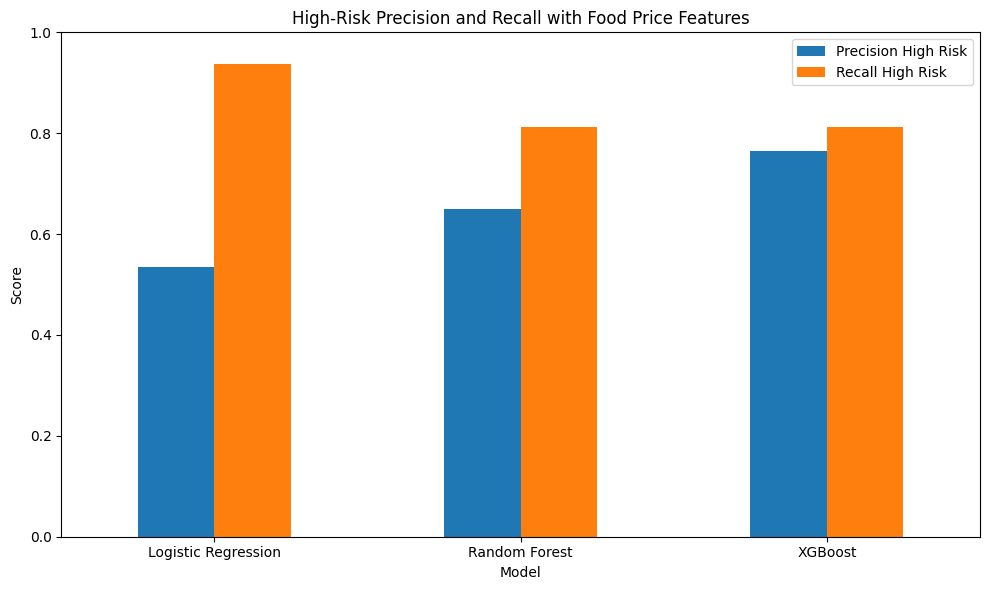

In [16]:
# Prepare high-risk precision and recall comparison for food price models

precision_recall_data = food_price_results[
    [
        "model",
        "precision_high_risk",
        "recall_high_risk"
    ]
].copy()

precision_recall_data = precision_recall_data.set_index("model")

# Plot precision and recall comparison

ax = precision_recall_data.plot(kind="bar", figsize=(10, 6))

plt.title("High-Risk Precision and Recall with Food Price Features")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(["Precision High Risk", "Recall High Risk"])
plt.tight_layout()
plt.show()

## **Precision and Recall Chart Interpretation**

The precision and recall chart shows the trade-off between detecting high-risk cases and avoiding false alarms.

Logistic Regression has the highest recall, meaning it detects the largest share of high-risk records. However, it has lower precision, meaning it produces more false alarms.

XGBoost has the best balance between precision and recall. It has stronger precision than Logistic Regression while still detecting most high-risk cases.

Random Forest is also balanced, but its overall performance is weaker than XGBoost in this experiment.

For the first food price modeling version, XGBoost is the strongest overall model, while Logistic Regression remains useful as a high-recall early-warning baseline.

## **XGBoost Feature Importance**

This section checks which features were most important in the XGBoost model.

Feature importance helps explain which signals the model used most when predicting high food insecurity risk.

This is useful because the project needs not only good performance, but also clear interpretation for a data analytics portfolio.

In [17]:
# Extract feature importance from the trained XGBoost model

xgb_classifier = xgb_model.named_steps["model"]

xgb_feature_importance = pd.DataFrame({
    "feature": model_features,
    "importance": xgb_classifier.feature_importances_
}).sort_values("importance", ascending=False)

xgb_feature_importance

,feature,importance
8,ndvi_6_month_mean,0.174119
7,ndvi_3_month_mean,0.126526
2,rainfall_6_month_total,0.108202
4,rainfall_6_month_avg,0.095678
12,final_staple_price_per_kg_6_month_avg,0.065043
9,ndvi_anomaly,0.059097
3,rainfall_3_month_avg,0.052305
1,rainfall_3_month_total,0.049848
11,final_staple_price_per_kg_3_month_avg,0.049650
0,mean_rainfall_mm,0.049353


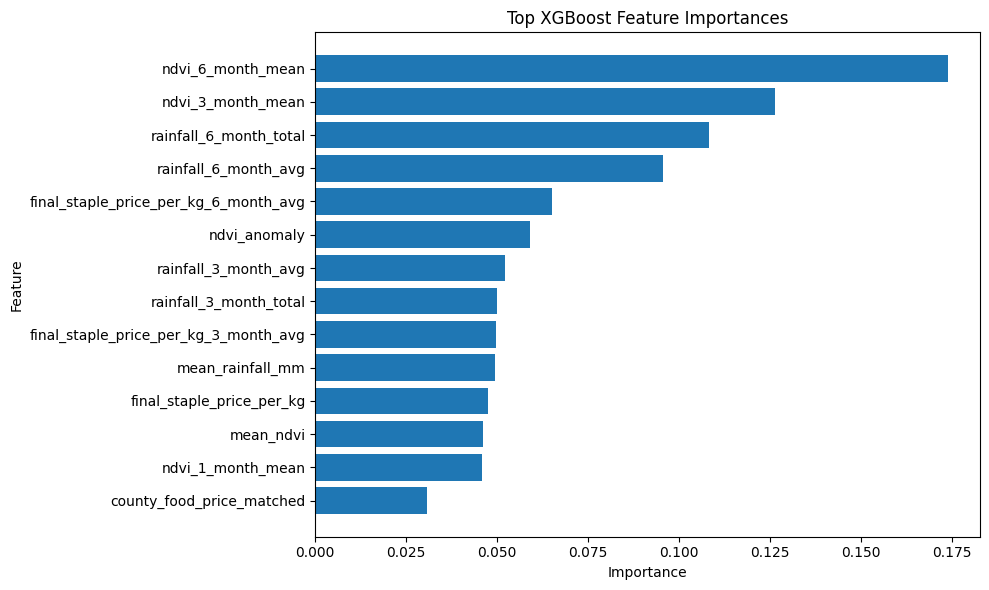

In [18]:
# Plot XGBoost feature importance

top_features = xgb_feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()

plt.title("Top XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## **XGBoost Feature Importance Interpretation**

The XGBoost feature importance results show that medium-term vegetation and rainfall features are the strongest predictors.

The most important features include `ndvi_6_month_mean`, `ndvi_3_month_mean`, `rainfall_6_month_total`, and `rainfall_6_month_avg`.

This suggests that food insecurity risk is strongly linked to vegetation conditions and rainfall patterns over several months.

Food price features also contributed to the model. The feature `final_staple_price_per_kg_6_month_avg` appears among the top features, showing that longer-term staple food price pressure adds useful predictive signal.

This supports the value of adding food price indicators to the early-warning model. The model is not relying only on climate and vegetation data; it is also using market pressure information.

## **Save Food Price Model Results**

This section saves the key outputs from the food price modeling notebook.

The saved files include:

- model comparison results
- before vs after food price improvement table
- XGBoost feature importance table

These files can be used later in the README, project report, and portfolio summary.

In [20]:
# Save model result outputs

model_results_output = PROCESSED_DIR / "model_results_food_prices.csv"
improvement_output = PROCESSED_DIR / "food_price_model_improvement_comparison.csv"
feature_importance_output = PROCESSED_DIR / "xgboost_food_price_feature_importance.csv"

# Save outputs
model_results.to_csv(model_results_output, index=False)
improvement_table.to_csv(improvement_output, index=False)
xgb_feature_importance.to_csv(feature_importance_output, index=False)

print("Saved food price model results to:")
print(model_results_output)

print("\nSaved food price improvement comparison to:")
print(improvement_output)

print("\nSaved XGBoost feature importance to:")
print(feature_importance_output)

Saved food price model results to:
..\02_data\processed\model_results_food_prices.csv

Saved food price improvement comparison to:
..\02_data\processed\food_price_model_improvement_comparison.csv

Saved XGBoost feature importance to:
..\02_data\processed\xgboost_food_price_feature_importance.csv


In [21]:
# Verify saved modeling output files

saved_model_results = pd.read_csv(model_results_output)
saved_improvement_table = pd.read_csv(improvement_output)
saved_feature_importance = pd.read_csv(feature_importance_output)

print("Saved model results shape:", saved_model_results.shape)
print("Saved improvement table shape:", saved_improvement_table.shape)
print("Saved feature importance shape:", saved_feature_importance.shape)

display(saved_model_results.head())
display(saved_improvement_table.head())
display(saved_feature_importance.head())

Saved model results shape: (3, 5)
Saved improvement table shape: (3, 13)
Saved feature importance shape: (14, 2)


,model,accuracy,f1_score,precision_high_risk,recall_high_risk
0,Logistic Regression + Food Prices,0.784615,0.681818,0.535714,0.9375
1,Random Forest + Food Prices,0.846154,0.722222,0.650000,0.8125
2,XGBoost + Food Prices,0.892308,0.787879,0.764706,0.8125


,model,accuracy_before_food_prices,accuracy_after_food_prices,accuracy_change,f1_score_before_food_prices,f1_score_after_food_prices,f1_score_change,precision_high_risk_before_food_prices,precision_high_risk_after_food_prices,precision_change,recall_high_risk_before_food_prices,recall_high_risk_after_food_prices,recall_change
0,XGBoost,0.8769,0.892308,0.015408,0.7778,0.787879,0.010079,0.7000,0.764706,0.064706,0.8750,0.8125,-0.0625
1,Random Forest,0.8769,0.846154,-0.030746,0.7647,0.722222,-0.042478,0.7222,0.650000,-0.072200,0.8125,0.8125,0.0000
2,Logistic Regression,0.7692,0.784615,0.015415,0.6667,0.681818,0.015118,0.5172,0.535714,0.018514,0.9375,0.9375,0.0000


,feature,importance
0,ndvi_6_month_mean,0.174119
1,ndvi_3_month_mean,0.126526
2,rainfall_6_month_total,0.108202
3,rainfall_6_month_avg,0.095678
4,final_staple_price_per_kg_6_month_avg,0.065043


## **Food Price Modeling Outputs Saved**

The food price modeling outputs were saved successfully.

Three processed result files were created:

- `model_results_food_prices.csv`
- `food_price_model_improvement_comparison.csv`
- `xgboost_food_price_feature_importance.csv`

These files document the model results after adding food price features, the before-and-after comparison against the rainfall + NDVI baseline, and the feature importance results for the best-performing XGBoost model.

The saved outputs can be used later in the project README, portfolio summary, and final model interpretation.

## **Notebook 14 Conclusion**

This notebook tested whether adding food price features improved the drought and food security early-warning model.

The food price features were added to the existing rainfall and NDVI feature set. Three models were tested:

- Logistic Regression
- Random Forest
- XGBoost

The results showed that food price features did not improve every model equally.

Logistic Regression improved slightly after adding food prices. Random Forest performed slightly worse. XGBoost achieved the strongest overall result after food price features were added.

The best overall model was XGBoost with rainfall, NDVI, and food price features. It achieved the highest accuracy and highest F1 score among the tested models.

The feature importance results showed that NDVI and rainfall features remained the strongest predictors. However, the 6-month staple food price average also appeared among the important features, showing that food price pressure added useful predictive signal.

This confirms that food price indicators can add value to the early-warning system, especially when combined with climate and vegetation indicators in a boosted tree model.

The main saved outputs from this notebook are:

- `model_results_food_prices.csv`
- `food_price_model_improvement_comparison.csv`
- `xgboost_food_price_feature_importance.csv`

These results can now be used in the README, project report, and portfolio summary.